In [1]:
#@title Cell 1 — Install & Import Dependencies
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q tensorflow-datasets opencv-python-headless imageio tqdm matplotlib scikit-learn pycocotools seaborn

import os, json, random, time, numpy as np, cv2, imageio, seaborn
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch, torchvision
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
from sklearn.metrics import accuracy_score
print("✅ Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


✅ Torch: 2.8.0+cu126 | CUDA available: True


In [2]:
#@title Cell 2 — Load DAVIS Dataset
import tensorflow_datasets as tfds

DATA_DIR = "/content/davis_data"
os.makedirs(DATA_DIR, exist_ok=True)
builder = tfds.builder("davis")
builder.download_and_prepare(download_dir=DATA_DIR)
ds = tfds.load("davis", split="train", data_dir=DATA_DIR)
print("✅ DAVIS dataset loaded successfully.")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /content/davis_data/davis/480p/incomplete.ZKG88T_2.1.0/davis-train.tfrecord*...:   0%|          | 0/…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /content/davis_data/davis/480p/incomplete.ZKG88T_2.1.0/davis-validation.tfrecord*...:   0%|         …

Dataset davis downloaded and prepared to /content/davis_data/davis/480p/2.1.0. Subsequent calls will reuse this data.
✅ DAVIS dataset loaded successfully.


In [3]:
#@title Cell 3 — Convert masks to bounding boxes
import tensorflow_datasets as tfds
from pathlib import Path
import numpy as np
import cv2
import imageio
from tqdm import tqdm
import os

IMG_DIR = Path("/content/davis_images")
IMG_DIR.mkdir(exist_ok=True)
images, annotations = [], []
img_id, ann_id = 1, 1

# Assuming `ds` is already loaded from Cell 2
# If not, you might need to add the loading code here or ensure Cell 2 runs successfully first.

for ex in tqdm(tfds.as_numpy(ds)):
    # Access image and mask data from the nested structure
    video_frames = ex["video"]["frames"]
    video_segmentations = ex["video"]["segmentations"]

    # Iterate through frames in the video
    for frame_idx in range(video_frames.shape[0]):
        img = video_frames[frame_idx]
        mask = video_segmentations[frame_idx].squeeze() # Remove the last dimension if it's 1

        h, w = img.shape[:2]
        img_path = IMG_DIR / f"frame_{img_id:05d}.jpg"
        imageio.imwrite(str(img_path), img)
        images.append({"id": img_id, "file_name": img_path.name, "width": w, "height": h})

        labels = np.unique(mask)[1:]
        for lbl in labels:
            ys, xs = np.where(mask == lbl)
            if xs.size == 0: continue
            x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
            # Ensure bbox is in [x1, y1, width, height] format and has positive width and height
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            if bbox_w > 0 and bbox_h > 0:
                annotations.append({"id": ann_id, "image_id": img_id, "category_id": 1, "bbox": [x1, y1, bbox_w, bbox_h]})
                ann_id += 1
        img_id += 1

coco_like = {"images": images, "annotations": annotations, "categories": [{"id":1,"name":"object"}]}
print(f"✅ {len(images)} images and {len(annotations)} boxes extracted.")

100%|██████████| 60/60 [01:15<00:00,  1.25s/it]

✅ 4209 images and 9622 boxes extracted.


In [7]:
#@title Cell 4 — Define PyTorch dataset
class DavisDataset(Dataset):
    def __init__(self, img_dir, anns):
        self.img_dir = img_dir
        self.imgs = {i['id']:i for i in anns['images']}
        self.ann_map = {}
        for a in anns['annotations']:
            self.ann_map.setdefault(a['image_id'], []).append(a)
        self.ids = list(self.imgs.keys())
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        meta = self.imgs[img_id]
        img = Image.open(self.img_dir / meta['file_name']).convert("RGB")
        anns = self.ann_map.get(img_id, [])
        boxes, labels = [], []
        for a in anns:
            x, y, w, h = a['bbox']
            boxes.append([x, y, x+w, y+h])
            labels.append(a['category_id'])
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        img = T.ToTensor()(img)
        return img, {"boxes": boxes, "labels": labels, "image_id": torch.tensor([img_id])}

def collate_fn(batch):
    # Filter out images with no annotations
    batch = [b for b in batch if b[1]["boxes"].numel() > 0]
    if not batch: # Return None if the batch is empty
        return None
    return tuple(zip(*batch))

dataset = DavisDataset(IMG_DIR, coco_like)
loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
print("✅ Dataset ready:", len(dataset))

✅ Dataset ready: 4209


In [8]:
#@title Cell 5 — Faster R-CNN (ResNet-50 with COCO Classification)
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Faster R-CNN pretrained on COCO (80 classes)
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="COCO_V1").to(device)
model.eval()

# Define COCO class names for label decoding
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv',
    'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]
print(f"✅ Loaded COCO-pretrained Faster R-CNN model ({len(COCO_CLASSES)-1} classes).")


✅ Loaded COCO-pretrained Faster R-CNN model (80 classes).


In [9]:
#@title Cell 6 — Train the model
def train_one_epoch(model, optimizer, loader):
    model.train(); losses=[]
    for batch in tqdm(loader, desc="Training"):
        # Skip empty batches
        if batch is None:
            continue
        imgs, tgts = batch
        imgs = [i.to(device) for i in imgs]
        tgts = [{k:v.to(device) for k,v in t.items()} for t in tgts]
        loss_dict = model(imgs, tgts)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

# Define optimizer and learning rate scheduler
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

EPOCHS = 5
train_losses = []
for e in range(EPOCHS):
    loss = train_one_epoch(model, optimizer, loader)
    train_losses.append(loss)
    scheduler.step()
    print(f"✅ Epoch {e+1}/{EPOCHS} | Loss: {loss:.4f}")

Training: 100%|██████████| 2105/2105 [21:06<00:00,  1.66it/s]


✅ Epoch 1/5 | Loss: 0.1871


Training: 100%|██████████| 2105/2105 [21:07<00:00,  1.66it/s]


✅ Epoch 2/5 | Loss: 0.1198


Training: 100%|██████████| 2105/2105 [21:09<00:00,  1.66it/s]


✅ Epoch 3/5 | Loss: 0.1028


Training: 100%|██████████| 2105/2105 [21:10<00:00,  1.66it/s]


✅ Epoch 4/5 | Loss: 0.0719


Training: 100%|██████████| 2105/2105 [21:10<00:00,  1.66it/s]

✅ Epoch 5/5 | Loss: 0.0639


Evaluating: 100%|██████████| 2105/2105 [09:37<00:00,  3.64it/s]


✅ Evaluation Results: {'Precision': 0.9645441388293835, 'Recall': 0.9697568072157808, 'F1': 0.9671429493232155, 'Accuracy': 0.936377320528211}


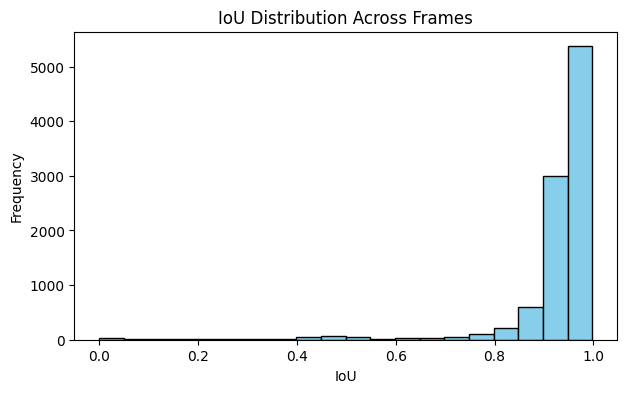

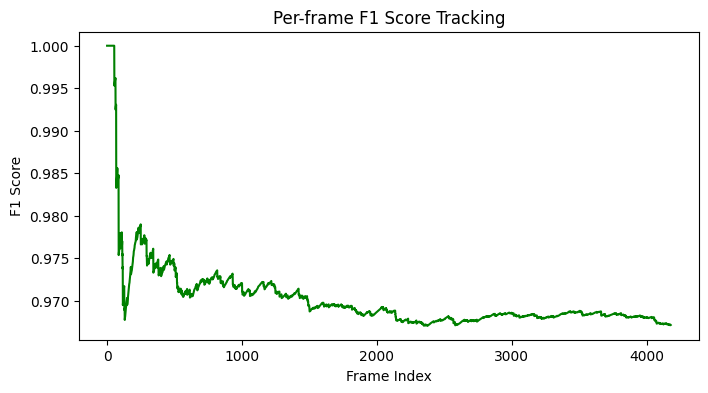

In [10]:
#@title Cell 7 — Evaluate + IoU distribution + per-frame metrics
def evaluate_model(model, loader, iou_thresh=0.7, score_thresh=0.6):
    model.eval()
    all_ious, frame_f1 = [], []
    TP=FP=FN=0
    with torch.no_grad():
        for imgs, tgts in tqdm(loader, desc="Evaluating"):
            imgs = [i.to(device) for i in imgs]
            outs = model(imgs)
            for out, tgt in zip(outs, tgts):
                gt_boxes = tgt["boxes"].cpu()
                pred_boxes = out["boxes"].cpu()
                scores = out["scores"].cpu()
                pred_boxes = pred_boxes[scores > score_thresh]
                if len(gt_boxes)==0 and len(pred_boxes)==0: continue
                if len(gt_boxes)>0 and len(pred_boxes)>0:
                    ious = box_iou(pred_boxes, gt_boxes)
                    best_iou = ious.max(dim=1).values
                    all_ious.extend(best_iou.tolist())
                    matched = (best_iou > iou_thresh).sum().item()
                    TP += matched
                    FP += len(pred_boxes) - matched
                    FN += len(gt_boxes) - matched
                    prec = TP/(TP+FP+1e-6); rec = TP/(TP+FN+1e-6)
                    f1 = 2*prec*rec/(prec+rec+1e-6)
                    frame_f1.append(f1)
    prec = TP/(TP+FP+1e-6)
    rec = TP/(TP+FN+1e-6)
    f1 = 2*prec*rec/(prec+rec+1e-6)
    acc = TP/(TP+FP+FN+1e-6)
    return {"Precision":prec,"Recall":rec,"F1":f1,"Accuracy":acc}, all_ious, frame_f1

results, ious, f1s = evaluate_model(model, loader)
print("✅ Evaluation Results:", results)

# Plot IoU distribution
plt.figure(figsize=(7,4))
plt.hist(ious, bins=20, color='skyblue', edgecolor='black')
plt.title("IoU Distribution Across Frames")
plt.xlabel("IoU"); plt.ylabel("Frequency")
plt.show()

# Plot F1 per frame
plt.figure(figsize=(8,4))
plt.plot(f1s, color='green')
plt.title("Per-frame F1 Score Tracking")
plt.xlabel("Frame Index"); plt.ylabel("F1 Score")
plt.show()


Saving photograph (1).jpg to photograph (1) (1).jpg
🔹 Testing on: photograph (1) (1).jpg


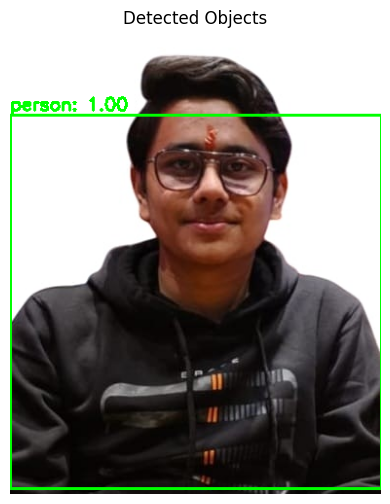

In [21]:
from google.colab import files
uploaded = files.upload()

for fname in uploaded.keys():
    print(f"🔹 Testing on: {fname}")
    if fname.lower().endswith(('.jpg','.jpeg','.png')):
        img = Image.open(fname).convert("RGB")
        t = T.ToTensor()(img).to(device)
        model.eval()
        with torch.no_grad():
            out = model([t])[0]
        boxes, scores, labels = out["boxes"].cpu().numpy(), out["scores"].cpu().numpy(), out["labels"].cpu().numpy()
        frame = np.array(img)
        for i, s in enumerate(scores):
            if s < 0.7: continue
            x1, y1, x2, y2 = boxes[i].astype(int)
            label_id = int(labels[i])
            class_name = COCO_CLASSES[label_id] if label_id < len(COCO_CLASSES) else "Unknown"
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(frame, f"{class_name}: {s:.2f}", (x1, max(15,y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        plt.figure(figsize=(8,6))
        plt.imshow(frame)
        plt.axis("off")
        plt.title("Detected Objects")
        plt.show()

    elif fname.lower().endswith(('.mp4','.avi')):
        cap = cv2.VideoCapture(fname)
        frames=[]
        model.eval()
        with torch.no_grad():
            while True:
                ret, frame = cap.read()
                if not ret: break
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                t = T.ToTensor()(Image.fromarray(rgb)).to(device)
                out = model([t])[0]
                topk = 3
                scores_all = out["scores"].cpu().numpy()
                labels_all = out["labels"].cpu().numpy()

                # Print top K for first detection
                for i in range(min(topk, len(scores_all))):
                    lab = labels_all[i]
                    print(f"{i+1}. {COCO_CLASSES[lab]}  ({scores_all[i]:.2f})")
                boxes, scores, labels = out["boxes"].cpu().numpy(), out["scores"].cpu().numpy(), out["labels"].cpu().numpy()
                for i, s in enumerate(scores):
                    if s < 0.5: continue
                    x1, y1, x2, y2 = boxes[i].astype(int)
                    label_id = int(labels[i])
                    class_name = COCO_CLASSES[label_id] if label_id < len(COCO_CLASSES) else "Unknown"
                    cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
                    cv2.putText(frame, f"{class_name}: {s:.2f}", (x1, max(10,y1-5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
                frames.append(frame[...,::-1])
        out_path = "/content/custom_test_output.mp4"
        imageio.mimsave(out_path, frames, fps=10)
        print(f"✅ Output video saved at: {out_path}")

In [22]:
#@title Cell 9 — Save Model
torch.save(model.state_dict(), "/content/fasterrcnn_resnet50_davis_complete.pth")
print("✅ Model saved successfully.")

✅ Model saved successfully.
